In [3]:
import io

import soundfile as sf
from datasets import Audio, load_dataset
from transformers import ClapModel, ClapProcessor
import torch
import torchaudio

# print("before dataset")

# librispeech_dummy = load_dataset("hf-internal-testing/librispeech_asr_dummy", "clean", split="validation")
# librispeech_dummy = librispeech_dummy.cast_column("audio", Audio(decode=False))
# audio_sample = librispeech_dummy[0]

# audio_info = audio_sample["audio"]
# if audio_info.get("bytes") is not None:
#     audio_array, sampling_rate = sf.read(io.BytesIO(audio_info["bytes"]))
# else:
#     audio_array, sampling_rate = sf.read(audio_info["path"])

# audio_tensor = torch.from_numpy(audio_array).float()
# if audio_tensor.ndim > 1:
#     audio_tensor = audio_tensor.mean(dim=-1)
# if sampling_rate != 48000:
#     audio_tensor = torchaudio.functional.resample(audio_tensor, sampling_rate, 48000)

print("before model")

model = ClapModel.from_pretrained("laion/clap-htsat-fused")

print("before processor")

processor = ClapProcessor.from_pretrained("laion/clap-htsat-fused")

print("before inference")

# inputs = processor(audio=audio_tensor.numpy(), sampling_rate=48000, return_tensors="pt")
# audio_embed = model.get_audio_features(**inputs)

before model
before processor
before inference


In [17]:
import torch
import torchaudio
import torch.nn.functional as F

def find_clap_second(audio_path, model, processor, window_sec=5.0, hop_sec=0.1, target_sr=48000):
    wav, sr = torchaudio.load(audio_path)

    if wav.size(0) > 1:
        wav = wav.mean(dim=0)
    else:
        wav = wav[0]

    if sr != target_sr:
        wav = torchaudio.functional.resample(wav, sr, target_sr)

    window_size = int(window_sec * target_sr)
    hop_size = int(hop_sec * target_sr)

    text_inputs = processor(text=["clap", "clapping sound", "sound of a clap"], return_tensors="pt", padding=True)
    text_features = model.get_text_features(**text_inputs)
    text_features = F.normalize(text_features, dim=-1)

    best_score = float("-inf")
    best_time = None

    for start in range(0, max(1, len(wav) - window_size + 1), hop_size):
        chunk = wav[start:start + window_size]
        if len(chunk) < window_size:
            break

        audio_inputs = processor(audio=chunk.numpy(), sampling_rate=target_sr, return_tensors="pt")
        audio_features = model.get_audio_features(**audio_inputs)
        audio_features = F.normalize(audio_features, dim=-1)

        score = (audio_features @ text_features.T).max().item()

        if score > best_score:
            best_score = score
            best_time = start / target_sr

    return best_time, best_score

In [18]:
best_time, best_score = find_clap_second("claps/ZOOM0759_Tr3.WAV", model, processor)
print(best_time, best_score)

11.3 0.19949093461036682


In [15]:
import matplotlib
import torch
import torchaudio
import torch.nn.functional as F
import matplotlib.pyplot as plt

def plot_clap_similarity_over_time(
    audio_path,
    model,
    processor,
    prompts=("clap", "clapping sound", "clapperboard"),
    window_sec=1.0,
    hop_sec=0.1,
    target_sr=48000,
):
    wav, sr = torchaudio.load(audio_path)

    if wav.size(0) > 1:
        wav = wav.mean(dim=0)
    else:
        wav = wav[0]

    if sr != target_sr:
        wav = torchaudio.functional.resample(wav, sr, target_sr)

    window_size = int(window_sec * target_sr)
    hop_size = int(hop_sec * target_sr)

    print("before text features")

    text_inputs = processor(text=list(prompts), return_tensors="pt", padding=True)
    with torch.no_grad():
        text_features = model.get_text_features(**text_inputs)
    text_features = F.normalize(text_features, dim=-1)

    times = []
    scores = {prompt: [] for prompt in prompts}

    print("before audio features")

    for start in range(0, max(1, len(wav) - window_size + 1), hop_size):
        chunk = wav[start:start + window_size]
        if len(chunk) < window_size:
            break

        print("before audio inputs")

        audio_inputs = processor(audio=chunk.numpy(), sampling_rate=target_sr, return_tensors="pt")
        with torch.no_grad():
            audio_features = model.get_audio_features(**audio_inputs)
        audio_features = F.normalize(audio_features, dim=-1)

        sim = (audio_features @ text_features.T).squeeze(0)  # shape: [num_prompts]

        times.append((start / target_sr) + window_sec / 2)
        for i, prompt in enumerate(prompts):
            scores[prompt].append(sim[i].item())

    plt.figure(figsize=(14, 6))
    for prompt in prompts:
        plt.plot(times, scores[prompt], label=prompt, linewidth=2)

    plt.xlabel("Time (seconds)")
    plt.ylabel("Similarity score")
    plt.title("CLAP similarity over time")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return times, scores

before text features
before audio features
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inputs
before audio inpu

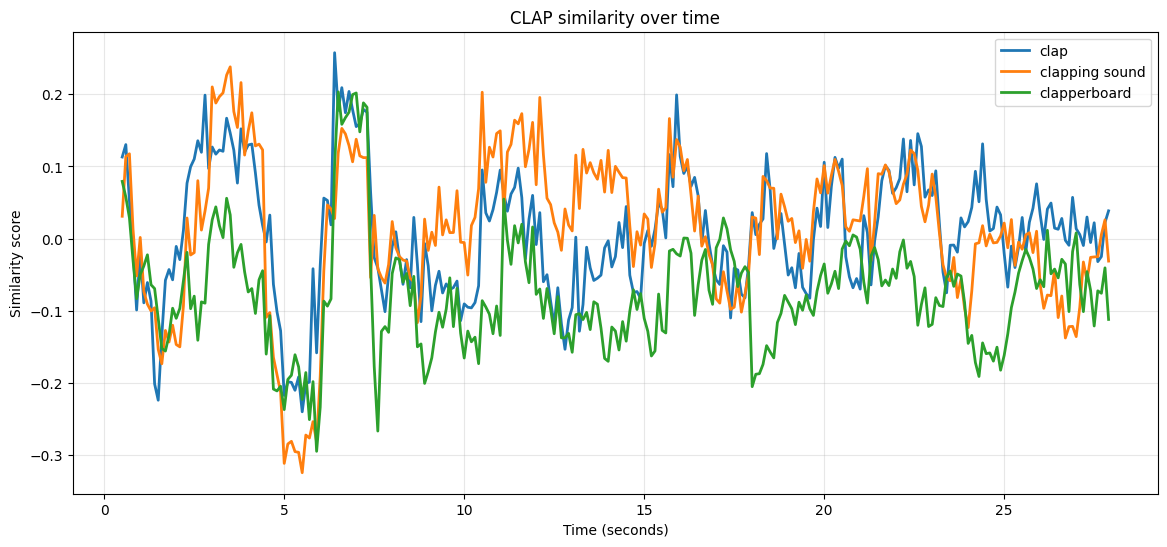

In [16]:
audio_path = "claps/ZOOM0759_Tr3.WAV"
times, scores = plot_clap_similarity_over_time(audio_path, model, processor)

windows: 275


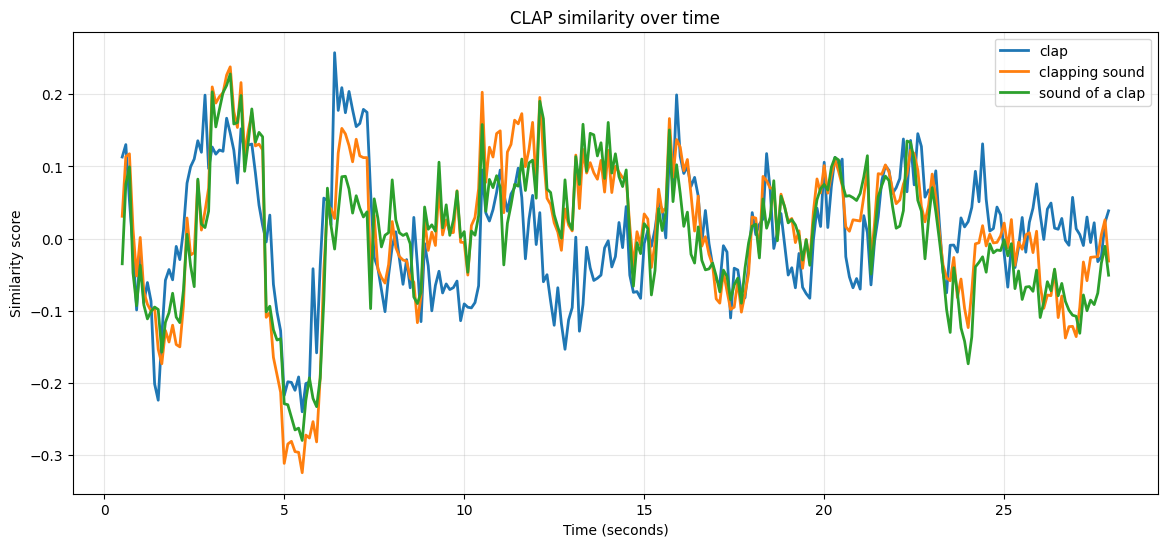

In [11]:
audio_path = "claps/ZOOM0759_Tr3.WAV"
times, scores = plot_clap_similarity_over_time(audio_path, model, processor)

In [19]:
import torch
import numpy as np
from transformers import ClapModel, ClapProcessor

model = ClapModel.from_pretrained("laion/clap-htsat-fused")
processor = ClapProcessor.from_pretrained("laion/clap-htsat-fused")
# model.eval()


ClapModel(
  (text_model): ClapTextModel(
    (embeddings): ClapTextEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): ClapTextEncoder(
      (layer): ModuleList(
        (0-11): 12 x ClapTextLayer(
          (attention): ClapTextAttention(
            (self): ClapTextSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ClapTextSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm):

In [37]:

# --- 1. Текстовые эмбеддинги (один раз) ---
text_keys = [
    "clapper board snap",
    "sharp clap sound",
    "loud click",
    "film slate clap",
    "clap noise",
    "clapperboard closing",
    "slate snap",
    "production clap",
    "sharp film clap",
    "clapper strike"
]
text_inputs = processor(text=text_keys, return_tensors="pt", padding=True)
with torch.no_grad():
    text_embeds = model.get_text_features(**text_inputs)  # [N, 512]
    text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)


In [39]:

# --- 2. Аудио эмбеддинги по окнам (один раз, потом кэш) ---
SAMPLE_RATE = 48000
WINDOW_SEC = 1
STEP_SEC = 0.5
window = int(WINDOW_SEC * SAMPLE_RATE)
step = int(STEP_SEC * SAMPLE_RATE)

# audio_array — твой numpy массив
audio_path 
wav, sr = torchaudio.load(audio_path)

if wav.size(0) > 1:
    wav = wav.mean(dim=0)
    audio_array = wav
else:
    wav = wav[0]
    audio_array = wav

if sr != SAMPLE_RATE:
    wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
    audio_array = wav  

timestamps = []
audio_embeds = []

for start in range(0, len(audio_array) - window, step):
    chunk = audio_array[start : start + window]
    inputs = processor(audios=chunk, sampling_rate=SAMPLE_RATE, return_tensors="pt")
    with torch.no_grad():
        emb = model.get_audio_features(**inputs)
        emb = emb / emb.norm(dim=-1, keepdim=True)
    audio_embeds.append(emb)
    timestamps.append(start / SAMPLE_RATE)

audio_embeds = torch.cat(audio_embeds)  # [T, 512]

# Сохрани на диск если нужно:
# torch.save({"embeds": audio_embeds, "timestamps": timestamps}, "cache.pt")


/var/folders/lt/75xqxt7561731l87vw1h2_3w0000gn/T/ipykernel_6976/1593893394.py:28: FutureWarning: `audios` is deprecated and will be removed in version v4.59.0 for `ClapProcessor.__call__`. Use `audio` instead.
  inputs = processor(audios=chunk, sampling_rate=SAMPLE_RATE, return_tensors="pt")


t=0.00s | best='clapper strike' 0.157 | top: 'clapper strike':0.157, 'production clap':0.143, 'loud click':0.079
t=2.50s | best='clapper strike' 0.275 | top: 'clapper strike':0.275, 'loud click':0.251, 'production clap':0.237
t=3.00s | best='clapper strike' 0.310 | top: 'clapper strike':0.310, 'production clap':0.295, 'loud click':0.293
t=3.50s | best='clapper strike' 0.294 | top: 'clapper strike':0.294, 'production clap':0.291, 'loud click':0.145
t=6.00s | best='film slate clap' 0.327 | top: 'film slate clap':0.327, 'sharp film clap':0.304, 'clapperboard closing':0.178
t=6.50s | best='sharp film clap' 0.338 | top: 'sharp film clap':0.338, 'film slate clap':0.303, 'clapperboard closing':0.225
t=7.50s | best='clapper strike' 0.118 | top: 'clapper strike':0.118, 'loud click':0.109, 'production clap':0.103
t=9.00s | best='clapper strike' 0.125 | top: 'clapper strike':0.125, 'loud click':0.065, 'production clap':0.055
t=9.50s | best='clapper strike' 0.108 | top: 'clapper strike':0.108, 'pr

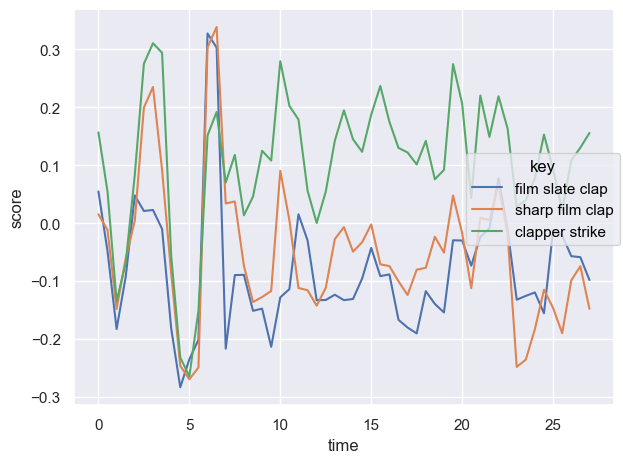

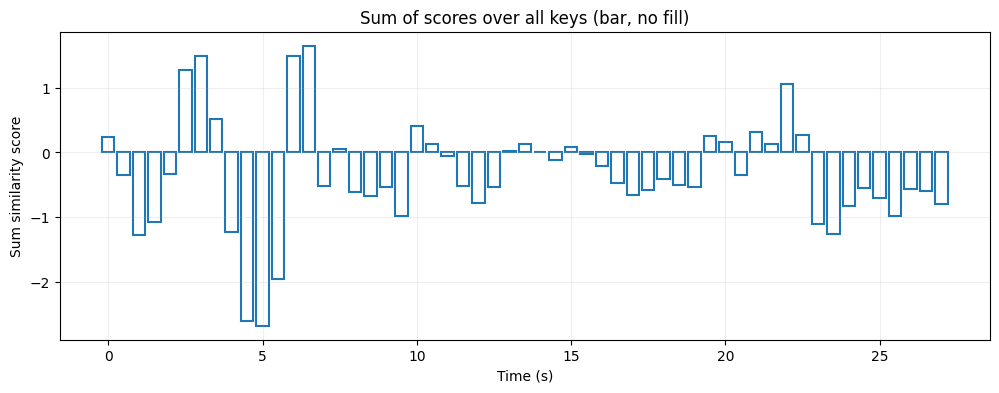

,time,score
0,0.0,0.233856
1,0.5,-0.350277
2,1.0,-1.282004
3,1.5,-1.076160
4,2.0,-0.327932
5,2.5,1.266360
6,3.0,1.488945
7,3.5,0.509858
8,4.0,-1.221275
9,4.5,-2.608541


In [ ]:
import pandas as pd
import seaborn.objects as so

# --- 3. Поиск — просто матричное умножение ---
# audio_embeds: [T, 512]
# text_embeds:  [N, 512]
scores = audio_embeds @ text_embeds.T  # [T, N]

# Максимум по всем текстовым ключам для каждого момента
best_score, best_key = scores.max(dim=-1)

# Порог
threshold = 0.10
hits = (best_score > threshold).nonzero(as_tuple=True)[0]

rows = []
n = 3

if len(hits) == 0:
    print("No hits above threshold")
else:
    for idx in hits:
        t = timestamps[int(idx)]
        bscore = float(best_score[idx].item())
        bkey = text_keys[int(best_key[idx])]
        topv, topi = scores[idx].topk(min(n, scores.size(1)))
        top_pairs = [(text_keys[int(i.item())], float(v.item())) for v, i in zip(topv, topi)]

        tops_str = ", ".join([f"'{k}':{v:.3f}" for k, v in top_pairs])
        print(f"t={t:.2f}s | best='{bkey}' {bscore:.3f} | top: {tops_str}")

        rows.append({
            "time_s": float(t),
            "best_key": bkey,
            "best_score": bscore,
            "top_keys": [k for k, _ in top_pairs],
            "top_scores": [v for _, v in top_pairs],
        })

df_hits = pd.DataFrame(rows)

# Get top 5 keys by max score
top_5_keys = best_key[best_score.argsort(descending=True)[:5]].unique().tolist()
top_5_keys = [text_keys[int(k)] for k in top_5_keys[:5]]

# Create dataframe for plotting top 5 keys
plot_data = []
for i, t in enumerate(timestamps):
    for j, key in enumerate(text_keys):
        plot_data.append({"time": t, "key": key, "score": scores[i, j].item()})

df_plot = pd.DataFrame(plot_data)

# Plot 1: Top 5 keys over time
import seaborn.objects as so
(so.Plot(df_plot[df_plot["key"].isin(top_5_keys)], x="time", y="score", color="key")
 .add(so.Line())

 .show())
# Sum scores per key and plot a bar for each key
df_key_sum = df_plot.groupby("key", as_index=False)["score"].sum().sort_values("score", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(df_key_sum["key"], df_key_sum["score"], color="C0")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Key")
plt.ylabel("Sum similarity score")
plt.title("Sum of scores per key")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

df_key_sum